# CSCI/MATH 485 Assignment
## Customer Churn Prediction with XGBoost
## Starter Notebook

This notebook is compatible with **Jupyter Notebook** and **Google Colab**.

This starter code is only to get you started. You can change any of the existing code here to complete all the tasks.

Complete all `TODO` sections. Make sure your final submission includes:
- data analysis,
- a tuned XGBoost model,
- your chosen main evaluation metric and justification,
- interpretation of top important features,
- and a final comparison with the baseline model.


## 1. Setup


In [ ]:
# If you are using Google Colab, uncomment the next line if xgboost is not installed.
# !pip install xgboost


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier


## 2. Load the Dataset

**Instructions for students**
- Load the IBM Telco Customer Churn dataset.
- Display the first few rows.
- Confirm the dataset shape.
- If the url doesn't work for you, download the csv file from the Canvas Assignment#4

In [7]:
url = "https://raw.githubusercontent.com/plotly/datasets/master/telco-customer-churn-by-IBM.csv"
df = pd.read_csv(url)

# Display the first 5 rows of the dataset (done below)
df.head()

# TODO:
# Display the shape of the dataset
print("Dataset shape:", df.shape)
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])
print(df.columns.tolist())

Dataset shape: (7043, 21)
Number of rows: 7043
Number of columns: 21
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


## Dataset Size and Target

The dataset contains customer demographic, account, service, and billing information. It has a moderate number of rows and columns, which makes it suitable for supervised machine learning. The target variable is **Churn**, which indicates whether a customer left the service.

## 3. Data Exploration

Complete the following:
- Print all column names
- Show data types
- Count missing values in each column
- Show the distribution of the target variable
- Write a short note: Is this a classification or regression problem? Why is this useful in business?


In [6]:
# TODO:
# Print column names
# Print data types
# Print missing values for each column
# Print value counts for the target column

print("Columns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nTarget distribution (counts):")
print(df["Churn"].value_counts())

print("\nTarget distribution:")
print(df["Churn"].value_counts(normalize=True))
# your code here

# Extra: display other information of the dataset that you think can be useful



Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values:
customerID          0
gender       

In [8]:
print("First 10 rows:")
display(df.head(10))

print("\nSummary statistics for numeric columns:")
display(df.describe())

print("\nSummary statistics including categorical columns:")
display(df.describe(include="all"))

First 10 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No



Summary statistics for numeric columns:


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Summary statistics including categorical columns:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


<Axes: title={'center': 'Distribution of Churn'}, xlabel='Churn'>

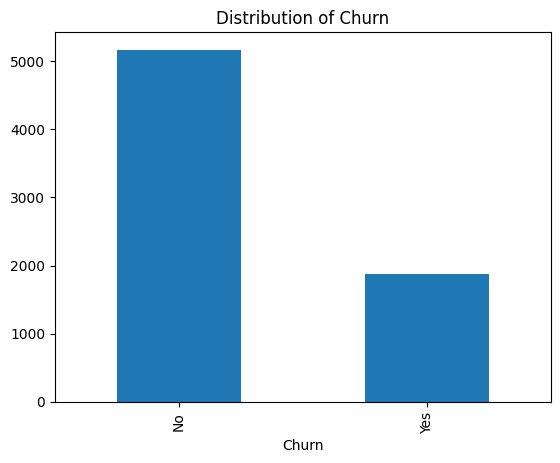

In [9]:
df["Churn"].value_counts().plot(kind="bar", title="Distribution of Churn")

**TODO (write your answer below):**

1. What kind of machine learning problem is this?
2. Why is churn prediction important in a business setting?

### Answers

**1. What kind of machine learning problem is this?**  
This is a **binary classification** problem because the target variable, **Churn**, has two possible outcomes: whether a customer churns or does not churn. The goal is to predict a class label rather than a continuous numeric value, so this is classification rather than regression.

**2. Why is churn prediction important in a business setting?**  
Churn prediction is important because losing existing customers reduces revenue and can increase the cost of acquiring replacement customers. In many businesses, retaining current customers is less expensive than finding new ones. By predicting which customers are most likely to leave, a company can take proactive steps such as targeted promotions, customer support outreach, or contract incentives to improve retention and reduce revenue loss.


### Initial Observations

From the early exploration, the dataset appears to contain a mix of numerical and categorical variables, which means preprocessing will be important before modeling. The target variable also appears to be somewhat imbalanced, so relying on accuracy alone may not be enough for evaluation. In addition, some columns such as **TotalCharges** may require cleaning because they may not be stored in a fully numeric format.

## 4. Basic Cleaning

Complet the following:
- Identify whether there is an ID column that should be removed
- Convert the target column into binary form if needed
- Convert any numeric-looking columns stored as text into numeric values


In [10]:
# Make a copy so the original data remains unchanged
df_clean = df.copy()

# 1. Drop any unnecessary identifier column(s)
# customerID is an identifier only and does not provide predictive customer behavior information
df_clean = df_clean.drop(columns=["customerID"])

# 2. Convert the target column to 0/1
# Yes -> 1 means customer churned, No -> 0 means customer stayed
df_clean["Churn"] = df_clean["Churn"].map({"Yes": 1, "No": 0})

# 3. Convert any numeric-looking columns stored as text into numeric type
# TotalCharges may contain blank strings, so invalid parsing is coerced to NaN
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

# 4. Display updated preview and confirm cleaning results
display(df_clean.head())

print("\nUpdated data types:")
print(df_clean.dtypes)

print("\nMissing values after cleaning:")
print(df_clean.isnull().sum())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1



Updated data types:
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Missing values after cleaning:
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
Payme

In [11]:
print("Number of missing values in TotalCharges after conversion:")
print(df_clean["TotalCharges"].isnull().sum())

print("\nTarget distribution after converting Churn to binary:")
print(df_clean["Churn"].value_counts())

Number of missing values in TotalCharges after conversion:
11

Target distribution after converting Churn to binary:
Churn
0    5174
1    1869
Name: count, dtype: int64


## Cleaning Decisions

I removed **customerID** because it is only an identifier and does not reflect customer behavior or service usage, so it would not meaningfully help prediction. I converted **Churn** from Yes/No into binary form (1/0) because machine learning models require the target variable in numeric form. I also converted **TotalCharges** to numeric format using `errors="coerce"` because this column may contain blank or invalid text entries. Instead of dropping those rows immediately, I allowed those invalid values to become missing values so they can be handled later in the preprocessing pipeline using imputation.

## 5. Define Features and Target

Complet the following:
- Define `X` and `y`
- Set the correct target column


In [12]:
# TODO:
# Replace with the correct target column name
target_col = "Churn"

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget value counts:")
print(y.value_counts())


Feature matrix shape: (7043, 19)
Target shape: (7043,)

Target value counts:
Churn
0    5174
1    1869
Name: count, dtype: int64


## Features and Target

The feature matrix **X** contains all cleaned predictor variables, while **y** contains the binary churn outcome. Separating features from the target variable is an important step because it prevents data leakage and keeps the modeling pipeline organized and reproducible.

## 6. Identify Numeric and Categorical Features

Complet the following:
- Create a list of numeric columns
- Create a list of categorical columns


In [15]:
# TODO:
# Identify numeric and categorical feature columns

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()


print("Numeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nNumber of numeric features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))



Numeric features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Number of numeric features: 4
Number of categorical features: 15


## Numeric and Categorical Features

The dataset contains both numerical and categorical predictors. Separating them is important because they require different preprocessing steps. Numerical features can be imputed directly, while categorical features must be imputed and then encoded into numeric form before they can be used by machine learning models.

## 7. Train/Test Split

Complet the following:
- Split the dataset into training and testing sets
- Use stratification if appropriate


In [16]:
# TODO:
# Create train/test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution (proportions):")
print(y_train.value_counts(normalize=True))

print("\nTest target distribution (proportions):")
print(y_test.value_counts(normalize=True))


X_train shape: (5634, 19)
X_test shape: (1409, 19)
y_train shape: (5634,)
y_test shape: (1409,)

Training target distribution (proportions):
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Test target distribution (proportions):
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


## Train/Test Split

I split the dataset into training and testing sets using an 80/20 split. I used **stratification** so that the proportion of churn and non-churn customers stays similar in both sets. This is important because it gives a fairer evaluation and reduces the chance that one split has an unusually different class balance than the other.

## 8. Preprocessing Pipelines

Build preprocessing for:
- numeric features
- categorical features

Then combine them into a `ColumnTransformer`.


In [18]:
# TODO:
# Build numeric preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

numeric_transformer

# TODO:
# Build categorical preprocessing pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

categorical_transformer

# TODO:
# Combine both preprocessing pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

preprocessor


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'TechSupport', 'StreamingTV',
                                  'StreamingMovies', 'Contract',
                                  'PaperlessBilling', 'PaymentMethod'])])

## Preprocessing Rationale

I used separate preprocessing steps for numerical and categorical variables so each type of data is handled appropriately. For numerical variables, I used **median imputation** because it is a simple and robust method for filling missing values without being overly influenced by outliers. For categorical variables, I used **most frequent imputation** so missing categories are replaced with the most common valid label. After that, I applied **one-hot encoding** to categorical features so that machine learning models can work with them in numeric form. I also used `handle_unknown="ignore"` so that if new categories appear in the test data, the pipeline will still run without errors.

## 9. Baseline Model: Logistic Regression

Complet the following:
- Train a Logistic Regression model as the baseline
- Generate predictions
- Evaluate using multiple metrics
- You may need to adjust `max_iter` if the model is not converging.


In [20]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=5000,random_state=42))
])

# TODO:
# Fit the baseline model
# Generate predicted labels
# Generate predicted probabilities

baseline_model.fit(X_train, y_train)

baseline_preds = baseline_model.predict(X_test)
baseline_probs = baseline_model.predict_proba(X_test)[:, 1]

print("First 10 baseline predictions:")
print(baseline_preds[:10])

print("\nFirst 10 baseline predicted probabilities:")
print(baseline_probs[:10])

First 10 baseline predictions:
[0 1 0 0 0 1 0 0 0 0]

First 10 baseline predicted probabilities:
[0.04679744 0.68286418 0.05681069 0.40474996 0.02170172 0.60257157
 0.4484619  0.1296346  0.00268418 0.39495712]


### Note on Logistic Regression Convergence

The Logistic Regression baseline initially produced a convergence warning because the optimizer reached the default iteration limit. I increased `max_iter` to 5000 so the model could converge more reliably. This keeps the baseline model stable while preserving the rest of the preprocessing pipeline.

In [21]:
# TODO:
# Compute and print:
# - Accuracy
# - Precision
# - Recall
# - F1-score
# - ROC-AUC

# Suggested variable names:
# baseline_preds
# baseline_probs

baseline_accuracy = accuracy_score(y_test, baseline_preds)
baseline_precision = precision_score(y_test, baseline_preds)
baseline_recall = recall_score(y_test, baseline_preds)
baseline_f1 = f1_score(y_test, baseline_preds)
baseline_roc_auc = roc_auc_score(y_test, baseline_probs)

print("Logistic Regression Baseline Metrics")
print("-----------------------------------")
print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-score : {baseline_f1:.4f}")
print(f"ROC-AUC  : {baseline_roc_auc:.4f}")


Logistic Regression Baseline Metrics
-----------------------------------
Accuracy : 0.8070
Precision: 0.6604
Recall   : 0.5615
F1-score : 0.6069
ROC-AUC  : 0.8421


In [22]:
# Optional but helpful
# TODO:
# Print classification report and confusion matrix

print("Classification Report:")
print(classification_report(y_test, baseline_preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test, baseline_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1035
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
[[927 108]
 [164 210]]


In [26]:
baseline_results = {
    "Model": "Logistic Regression",
    "Accuracy": baseline_accuracy,
    "Precision": baseline_precision,
    "Recall": baseline_recall,
    "F1-score": baseline_f1,
    "ROC-AUC": baseline_roc_auc
}

baseline_results_df = pd.DataFrame([baseline_results])
baseline_results_df

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.806955,0.660377,0.561497,0.606936,0.842101


## Baseline Model Interpretation

The Logistic Regression baseline achieved an accuracy of **0.8070**, which shows that it performs reasonably well overall on the test data. Its **precision of 0.6604** means that when the model predicts churn, it is correct about two-thirds of the time. Its **recall of 0.5615** shows that it identifies a little over half of the actual churners, which suggests that some at-risk customers are still being missed. The **F1-score of 0.6069** reflects a moderate balance between precision and recall, while the **ROC-AUC of 0.8421** indicates that the model does a strong job separating churners from non-churners across different classification thresholds. Overall, this baseline gives a solid reference point, but the relatively lower recall suggests there may be room for improvement with a more flexible model such as XGBoost.

## 10. Choose Your Main Evaluation Metric

Choose **one main metric** for this churn problem.

You must explain:
- which metric you chose,
- why it is appropriate,
- and why it is more informative than accuracy alone for this problem.


**TODO (write your answer below):**

## Main Evaluation Metric: F1-score

For this churn prediction problem, I chose **F1-score** as the primary evaluation metric. F1-score is appropriate because it balances **precision** and **recall**, which are both important in churn prediction. Precision matters because if the model labels too many customers as likely to churn when they actually will not, the company may waste time and resources on unnecessary retention efforts. Recall matters because if the model fails to identify real churners, the business may lose valuable customers who could have been retained.

I consider F1-score more informative than accuracy alone in this context because churn prediction often involves some degree of class imbalance. A model can achieve a high accuracy simply by predicting the majority class well, even if it performs poorly at identifying actual churners. F1-score gives a more balanced view of model usefulness by considering both false positives and false negatives. In this business setting, that makes it a stronger primary metric for comparing models.


## 11. XGBoost Model

Complet the following:
- Build an XGBoost pipeline
- Tune at least 3 hyperparameters
- Use either `GridSearchCV` or your own tuning approach


In [27]:
xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

xgb_model

# TODO:
# Define a hyperparameter grid with at least 3 hyperparameters
param_grid = {
    "classifier__n_estimators": [100, 200],
    "classifier__max_depth": [3, 5, 7],
    "classifier__learning_rate": [0.05, 0.1],
    "classifier__subsample": [0.8, 1.0]
}

param_grid


{'classifier__n_estimators': [100, 200],
 'classifier__max_depth': [3, 5, 7],
 'classifier__learning_rate': [0.05, 0.1],
 'classifier__subsample': [0.8, 1.0]}

## XGBoost Hyperparameter Tuning Rationale

I tuned four important XGBoost hyperparameters: **n_estimators**, **max_depth**, **learning_rate**, and **subsample**. I selected these because they strongly influence model complexity, learning behavior, and overfitting control. The number of estimators controls how many boosting rounds are used, max depth controls how complex each tree can become, learning rate controls how aggressively the model learns from each boosting step, and subsample helps regularize the model by using only a portion of the training data for each tree. Tuning these parameters helps improve model performance while reducing the risk of underfitting or overfitting.

In [28]:
# TODO:
# Run GridSearchCV (or perform manual tuning)
# Choose a scoring metric that matches your selected main evaluation metric

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search

# TODO:
# Fit grid search on training data

grid_search.fit(X_train, y_train)


Fitting 3 folds for each of 24 candidates, totalling 72 fits


GridSearchCV(cv=3,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median'))]),
                                                                         ['SeniorCitizen',
                                                                          'tenure',
                                                                          'MonthlyCharges',
                                                                          'TotalCharges']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         [...
                                                      max_depth=None,
                                                      max_leaves=None,
                                                      min_child_weight=None,
                                                      missing=nan,
                                                      monotone_constraints=None,
                                                      multi_strategy=None,
                                                      n_estimators=None,
                                                      n_jobs=None,
                                                      num_parallel_tree=None, ...))]),
             n_jobs=-1,
             param_grid={'classifier__learning_rate': [0.05, 0.1],
                         'classifier__max_depth': [3, 5, 7],
                         'classifier__n_estimators': [100, 200],
                         'classifier__subsample': [0.8, 1.0]},
             scoring='f1', verbose=1)

In [29]:
# TODO:
# Print the best hyperparameters
# Save the best model

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validated F1-score:")
print(grid_search.best_score_)

best_model = grid_search.best_estimator_


Best parameters:
{'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__n_estimators': 100, 'classifier__subsample': 0.8}

Best cross-validated F1-score:
0.5959724860650745


## Best XGBoost Model

I used grid search with cross-validation to select the XGBoost hyperparameters that produced the best **F1-score** on the training data. This makes the tuning process consistent with my chosen primary evaluation metric and helps ensure that the final model is optimized for balanced churn detection rather than accuracy alone.

## 12. Evaluate the Tuned XGBoost Model

Evaluate XGBoost using the same metrics as the baseline.


In [30]:
# TODO:
# Generate predictions and probabilities using the best XGBoost model

# Suggested variable names:
# xgb_preds
# xgb_probs
xgb_preds = best_model.predict(X_test)
xgb_probs = best_model.predict_proba(X_test)[:, 1]

print("First 10 XGBoost predictions:")
print(xgb_preds[:10])

print("\nFirst 10 XGBoost predicted probabilities:")
print(xgb_probs[:10])

First 10 XGBoost predictions:
[0 1 0 0 0 1 1 0 0 0]

First 10 XGBoost predicted probabilities:
[0.01468735 0.84929544 0.06357484 0.30324    0.00934592 0.6630158
 0.51421845 0.08811733 0.01150669 0.34533912]


In [31]:
# TODO:
# Compute and print:
# - Accuracy
# - Precision
# - Recall
# - F1-score
# - ROC-AUC

xgb_accuracy = accuracy_score(y_test, xgb_preds)
xgb_precision = precision_score(y_test, xgb_preds)
xgb_recall = recall_score(y_test, xgb_preds)
xgb_f1 = f1_score(y_test, xgb_preds)
xgb_roc_auc = roc_auc_score(y_test, xgb_probs)

print("Tuned XGBoost Metrics")
print("---------------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1-score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")


Tuned XGBoost Metrics
---------------------
Accuracy : 0.8034
Precision: 0.6633
Recall   : 0.5267
F1-score : 0.5872
ROC-AUC  : 0.8450


In [32]:
# Optional but helpful
# TODO:
# Print classification report and confusion matrix

print("Classification Report:")
print(classification_report(y_test, xgb_preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_preds))


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.53      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409

Confusion Matrix:
[[935 100]
 [177 197]]


In [33]:
xgb_results = {
    "Model": "Tuned XGBoost",
    "Accuracy": xgb_accuracy,
    "Precision": xgb_precision,
    "Recall": xgb_recall,
    "F1-score": xgb_f1,
    "ROC-AUC": xgb_roc_auc
}

xgb_results_df = pd.DataFrame([xgb_results])
display(xgb_results_df)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Tuned XGBoost,0.803407,0.6633,0.526738,0.587183,0.845021


## Tuned XGBoost Model Interpretation

The tuned XGBoost model achieved an accuracy of **0.8034**, a precision of **0.6633**, a recall of **0.5267**, an F1-score of **0.5872**, and a ROC-AUC of **0.8450**. Compared with the Logistic Regression baseline, XGBoost produced a slightly higher precision and slightly higher ROC-AUC, which suggests that it may rank churn risk a little better across thresholds and is slightly more selective when predicting churn. However, it performed worse on **recall** and **F1-score**, which is important because the main evaluation metric for this assignment is F1-score. Since F1-score balances precision and recall, the Logistic Regression model remains the stronger model overall in this specific comparison. This result shows that a more advanced model does not always outperform a simpler baseline, especially when the baseline already fits the structure of the data reasonably well.

## 13. Feature Importance

Use the trained XGBoost model to:
- extract feature importances,
- recover transformed feature names,
- display the top 5 to 10 most important features.


In [36]:
# TODO:
# Access the fitted preprocessor and fitted XGBoost classifier from the pipeline

# Example structure:
# fitted_preprocessor = best_model.named_steps["preprocessor"]
# fitted_xgb = best_model.named_steps["classifier"]

fitted_preprocessor = best_model.named_steps["preprocessor"]
fitted_xgb = best_model.named_steps["classifier"]

print("Fitted preprocessor:")
print(fitted_preprocessor)

print("\nFitted XGBoost classifier:")
print(fitted_xgb)


Fitted preprocessor:
ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median'))]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup', 'DeviceProtection',
                                  'Te

In [37]:
# TODO:
# Get transformed feature names
# Get feature importances
# Create a DataFrame sorted by importance

# Example structure:
# feature_names = fitted_preprocessor.get_feature_names_out()
# importances = fitted_xgb.feature_importances_

feature_names = fitted_preprocessor.get_feature_names_out()
importances = fitted_xgb.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

display(importance_df.head(10))


,Feature,Importance
36,cat__Contract_Month-to-month,0.451029
16,cat__InternetService_Fiber optic,0.097233
18,cat__OnlineSecurity_No,0.068518
14,cat__MultipleLines_Yes,0.049330
27,cat__TechSupport_No,0.035234
38,cat__Contract_Two year,0.027475
43,cat__PaymentMethod_Electronic check,0.026844
1,num__tenure,0.025286
37,cat__Contract_One year,0.019562
35,cat__StreamingMovies_Yes,0.018357


In [40]:
# TODO:
# Display the top 10 most important features

top_10_features = importance_df.head(10)
print("Top 10 Most Important Features:")
display(top_10_features)


Top 10 Most Important Features:


,Feature,Importance
36,cat__Contract_Month-to-month,0.451029
16,cat__InternetService_Fiber optic,0.097233
18,cat__OnlineSecurity_No,0.068518
14,cat__MultipleLines_Yes,0.049330
27,cat__TechSupport_No,0.035234
38,cat__Contract_Two year,0.027475
43,cat__PaymentMethod_Electronic check,0.026844
1,num__tenure,0.025286
37,cat__Contract_One year,0.019562
35,cat__StreamingMovies_Yes,0.018357


## 14. Interpret the Top Features

Write a short interpretation of the most important features.

Your explanation should:
- use plain language,
- connect features to churn behavior,
- and explain what the company might learn from them.


**TODO (write your answer below):**

## Interpretation of the Top Features

The feature importance results show that the tuned XGBoost model relied most heavily on variables related to **contract type, service characteristics, support options, payment behavior, and customer tenure** when predicting churn. The most important feature by far was **Contract_Month-to-month**, which suggests that customers on month-to-month contracts are much more likely to churn than customers on longer contracts. This makes intuitive sense because these customers have less long-term commitment and can leave more easily if they become dissatisfied or find a better offer elsewhere.

The second most important feature was **InternetService_Fiber optic**. This suggests that customers with fiber optic service may have a different churn pattern than customers with other internet service types. One possible explanation is that these customers may have higher expectations about performance, value, or price, so dissatisfaction could lead them to leave more quickly. Related service features such as **OnlineSecurity_No** and **TechSupport_No** were also important, which may mean that customers without additional protection or support services are more likely to churn. This could reflect weaker customer engagement, lower perceived value, or greater frustration when technical issues occur.

Another important feature was **MultipleLines_Yes**, which suggests that the number or complexity of subscribed services may also influence churn behavior. Features such as **StreamingMovies_Yes** may indicate that customers with certain entertainment usage profiles behave differently from others, possibly because bundled services affect how they perceive value. The importance of **PaymentMethod_Electronic check** suggests that billing and payment behavior may also be linked to churn risk. Customers using electronic check may represent a group with weaker long-term commitment or different billing habits than customers using automatic payment methods.

Contract-related features appeared multiple times in the top 10, including **Contract_Two year** and **Contract_One year**, along with **tenure**. This reinforces the idea that customer commitment and length of relationship are central to churn prediction. In general, customers with longer tenure and more stable contract arrangements are often less likely to leave, while customers with shorter relationships or less commitment are more likely to churn.

Overall, these results suggest that churn is strongly associated with **low customer commitment, limited support services, certain billing behaviors, and specific service types**. From a business perspective, the company could use this information to identify high-risk customer groups earlier and target them with proactive retention strategies.


### Business Implications of the Feature Importance Results

These feature importance results provide several practical insights for customer retention strategy. First, customers on **month-to-month contracts** appear to be the highest-risk group, so the company should focus retention campaigns on these customers before they decide to leave. Second, customers with **fiber optic internet** may need closer monitoring to ensure that service quality, pricing, and customer expectations remain aligned. Third, the importance of **OnlineSecurity_No** and **TechSupport_No** suggests that support-related services may play a role in customer loyalty, so the company may benefit from promoting value-added support and security options to vulnerable customers.

The results also suggest that **payment behavior** can provide useful churn signals. Customers paying by **electronic check** may be less committed or less integrated into automatic billing systems, so encouraging more stable payment arrangements may help reduce churn risk. Finally, the importance of **tenure** and contract length shows that early-stage customers may need stronger onboarding, follow-up, and relationship-building efforts. Overall, these findings suggest that churn prevention should not rely on one broad strategy, but should instead target specific customer groups based on contract type, service bundle, support usage, and billing behavior.

## 15. Final Comparison: Logistic Regression vs XGBoost

Compare the two models using your results.

Your discussion should answer:
- Which model performed better?
- On which metric(s)?
- Why might XGBoost perform better on this dataset?
- What is one limitation of XGBoost?


In [41]:
# TODO:
# Print a side-by-side comparison of the main metrics
# for Logistic Regression and XGBoost

metric_comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Logistic Regression": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_roc_auc
    ],
    "Tuned XGBoost": [
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1,
        xgb_roc_auc
    ]
})

display(metric_comparison)


,Metric,Logistic Regression,Tuned XGBoost
0,Accuracy,0.806955,0.803407
1,Precision,0.660377,0.663300
2,Recall,0.561497,0.526738
3,F1-score,0.606936,0.587183
4,ROC-AUC,0.842101,0.845021


**TODO (write your answer below):**

## Final Comparison: Logistic Regression vs XGBoost

The final results show that **Logistic Regression** performed better overall than the tuned **XGBoost** model for this assignment when judged by the selected primary metric, **F1-score**. Logistic Regression achieved an **F1-score of 0.6069**, compared with **0.5872** for XGBoost. Logistic Regression also performed better on **accuracy** (**0.8070** vs **0.8034**) and **recall** (**0.5615** vs **0.5267**), while XGBoost performed slightly better on **precision** (**0.6633** vs **0.6604**) and **ROC-AUC** (**0.8450** vs **0.8421**).

Because **F1-score** was chosen as the primary evaluation metric, Logistic Regression is the stronger model in this analysis. This is especially important in churn prediction because F1-score balances precision and recall. Although XGBoost was slightly more precise and had a marginally better ROC-AUC, it identified fewer actual churners, which caused its recall and F1-score to fall below the baseline.

One reason XGBoost may not have outperformed Logistic Regression here is that the churn patterns in this dataset may already be captured reasonably well by the simpler linear model after preprocessing and one-hot encoding. In other words, the dataset may contain strong categorical signals, such as contract type and service choices, that Logistic Regression can already use effectively. XGBoost is often powerful because it can model nonlinear relationships and feature interactions, but in this case those added capabilities did not produce a better overall F1-score.

One important limitation of XGBoost is that it is **less interpretable** than Logistic Regression and usually requires more tuning effort. That makes it harder to explain to non-technical stakeholders and more time-consuming to optimize. In contrast, Logistic Regression is simpler, easier to understand, and in this case performed better on the main metric.

Overall, based on the selected primary metric and the broader set of test results, **Logistic Regression was the better model for this assignment**.


### Additional Reflection

This result is a useful reminder that model complexity does not automatically guarantee better predictive performance. A more advanced model such as XGBoost can be very powerful, but its value depends on whether the data contains patterns that actually benefit from that extra flexibility. In this case, the simpler Logistic Regression model remained highly competitive and even stronger on the primary metric. From a practical business perspective, that matters because a simpler model can sometimes offer a better balance of performance, interpretability, and ease of deployment.

## Conclusion

In this assignment, I analyzed the IBM Telco Customer Churn dataset, performed data cleaning and preprocessing, built a Logistic Regression baseline, tuned an XGBoost model, and compared both models using multiple evaluation metrics. I selected **F1-score** as the primary metric because churn prediction requires a balanced view of precision and recall rather than relying on accuracy alone. Based on this metric, the **Logistic Regression** model performed better than the tuned XGBoost model on the test set.

The feature importance analysis from XGBoost showed that **contract type, internet service type, support-related features, payment method, and tenure** were the most influential factors in churn prediction. In particular, **month-to-month contracts** appeared to be the strongest indicator of churn risk, suggesting that customer commitment is a major factor in retention. These findings provide useful business insight because they can help the company identify high-risk customer groups and design more targeted retention strategies.

A key lesson from this assignment is that a more complex model does not always outperform a simpler one. Although XGBoost is a powerful method, the Logistic Regression baseline remained more effective on the selected primary metric and also offered greater simplicity and interpretability. In a real business setting, that tradeoff can be very important when choosing a model for deployment.

## 16. Suggested Submission Checklist

Before submitting, make sure your notebook includes:
- completed code cells,
- outputs for each section,
- your selected main evaluation metric and justification,
- tuned XGBoost hyperparameters,
- feature importance results,
- interpretation of important features,
- and a final comparison of the two models.


In [43]:
metric_comparison_rounded = metric_comparison.copy()
metric_comparison_rounded["Logistic Regression"] = metric_comparison_rounded["Logistic Regression"].round(4)
metric_comparison_rounded["Tuned XGBoost"] = metric_comparison_rounded["Tuned XGBoost"].round(4)

display(metric_comparison_rounded)

top_10_features_clean = top_10_features.copy()
top_10_features_clean["Importance"] = top_10_features_clean["Importance"].round(4)

display(top_10_features_clean)

,Metric,Logistic Regression,Tuned XGBoost
0,Accuracy,0.8070,0.8034
1,Precision,0.6604,0.6633
2,Recall,0.5615,0.5267
3,F1-score,0.6069,0.5872
4,ROC-AUC,0.8421,0.8450


,Feature,Importance
36,cat__Contract_Month-to-month,0.4510
16,cat__InternetService_Fiber optic,0.0972
18,cat__OnlineSecurity_No,0.0685
14,cat__MultipleLines_Yes,0.0493
27,cat__TechSupport_No,0.0352
38,cat__Contract_Two year,0.0275
43,cat__PaymentMethod_Electronic check,0.0268
1,num__tenure,0.0253
37,cat__Contract_One year,0.0196
35,cat__StreamingMovies_Yes,0.0184
